In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

# Keep routine progress messages out of the teaching output.
scarf.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq", destination="scarf_datasets", zarr=True
)

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

In [2]:
# Open the datastore for the following analysis.
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
# Open the prepared baseline for the comparisons below.
baseline = ds.pipeline.open(label="docs_default")
# Keep the normalization fixed while comparing reductions.
normalized = baseline["normalized"]
# Reuse the saved UMAP coordinates.
umap = baseline["umap"]
# Inspect the opened assays and their dimensions.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

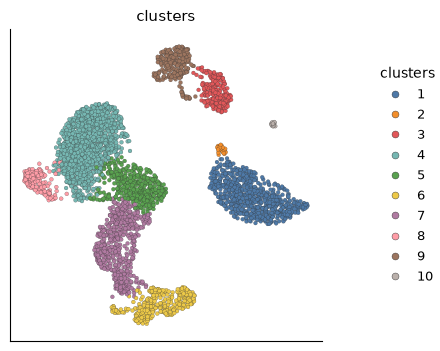

In [3]:
# Inspect the baseline clusters before changing PCA dimensions.
ds.plots.embedding(run=baseline, color_by="clusters")

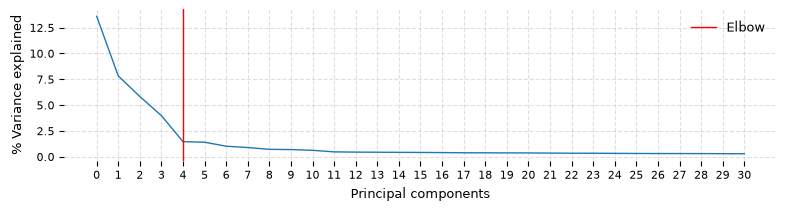

In [4]:
# Compare three PCA dimension counts.
dimension_counts = (10, 15, 30)
# Reuse the baseline graph built from 15 PCs.
graph_15 = baseline["connectivity_map"]
# Reuse the baseline clustering for the 15-PC comparison.
cluster_refs = {15: baseline["leiden_0.5"]}
# Rebuild only the alternatives to the saved 15-PC analysis.
for dimensions in (10, 30):
    # Fit PCA with the current dimension count.
    pca = ds.run_pca(
        normalized, dims=dimensions, show_elbow_plot=dimensions == 30
    )
    # Build an index over these PCA coordinates.
    ann = ds.build_ann_index(pca)
    # Query the same number of neighbors for every candidate.
    neighbors = ds.query_neighbors(ann, k=11)
    # Build connectivity from this candidate's neighbors.
    graph = ds.build_connectivity_map(neighbors)
    # Cluster this candidate graph at the fixed resolution.
    cluster_refs[dimensions] = ds.run_leiden_clustering(graph, resolution=0.5)

# Reuse the same initialization for the layout comparisons.
initialization_15 = baseline["embedding_initialization"]
# Load each candidate's labels in the common cell order.
cluster_values = {
    dimensions: np.asarray(
        ds.load_artifact(cluster_refs[dimensions])["values"][:]
    )
    for dimensions in dimension_counts
}

In [5]:
# Count cells per cluster for each PCA dimension count.
cluster_sizes = pd.DataFrame(
    {
        dimensions: pd.Series(cluster_values[dimensions]).value_counts()
        for dimensions in dimension_counts
    }
).fillna(0).astype(int)
# Label both comparison axes before displaying the cluster sizes.
cluster_sizes.rename_axis(index="cluster", columns="PCs")

PCs,10,15,30
cluster,,,
1,572,716,704
2,157,25,237
3,248,239,1315
4,619,1241,317
5,287,434,295
6,665,319,144
7,659,552,258
8,320,151,609
9,149,256,17


In [6]:
# Compare partition agreement between PCA dimension counts.
pd.Series(
    {
        f"{first} vs {second} PCs": ds.metric_label_concordance(
            cluster_refs[first], cluster_refs[second]
        )
        for first, second in combinations(dimension_counts, 2)
    },
    name="adjusted Rand index",
)

10 vs 15 PCs    0.636799
10 vs 30 PCs    0.652961
15 vs 30 PCs    0.832587
Name: adjusted Rand index, dtype: float64

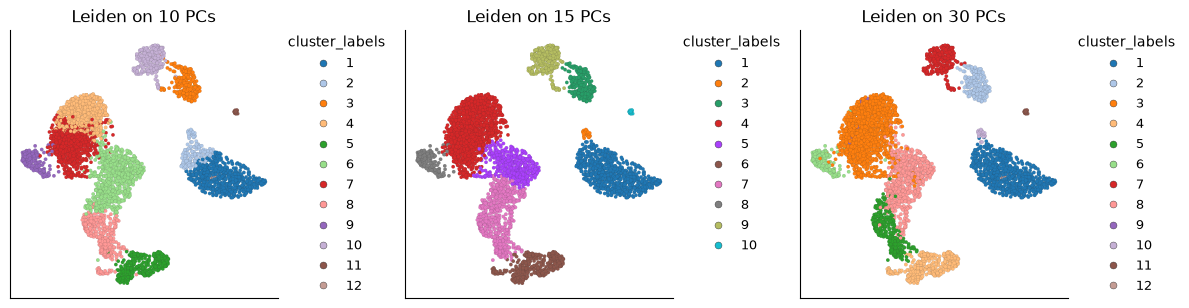

In [7]:
# Create one plotting axis for each comparison panel.
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
# Draw each comparison on its own labeled axis.
for axis, dimensions in zip(axes, dimension_counts, strict=True):
    # Place each candidate clustering on the common baseline UMAP.
    ds.plots.embedding(
        layout=umap,
        color_by=cluster_refs[dimensions],
        target=axis,
        show_titles=False,
        show=False,
    )
    # Label the panel with the quantity being compared.
    axis.set_title(f"Leiden on {dimensions} PCs")
# Adjust spacing so panel labels remain readable.
figure.tight_layout()
# Display the completed figure.
figure

In [8]:
# Change UMAP packing while holding the graph and initialization fixed.
umap_tight = ds.run_umap(graph_15, initialization_15, min_dist=0.1)

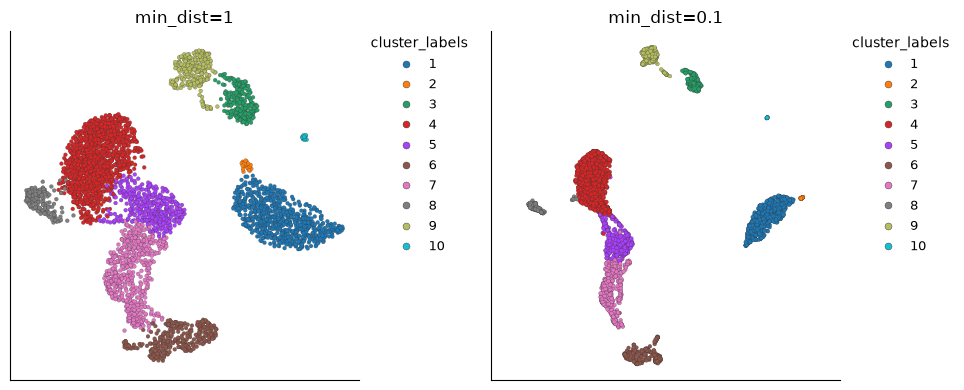

In [9]:
# Create one plotting axis for each comparison panel.
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
# Draw each comparison on its own labeled axis.
for axis, layout, title in zip(
    axes, (umap, umap_tight), ("min_dist=1", "min_dist=0.1"), strict=True
):
    # Compare UMAP packing with the same cluster colors.
    ds.plots.embedding(
        layout=layout,
        color_by=cluster_refs[15],
        target=axis,
        show_titles=False,
        show=False,
    )
    # Label the panel with the quantity being compared.
    axis.set_title(title)
# Adjust spacing so panel labels remain readable.
figure.tight_layout()
# Display the completed figure.
figure

In [10]:
# Fit densMAP to the same graph and initialization.
densmap = ds.run_umap(graph_15, initialization_15, use_density_map=True)

In [11]:
# Fit t-SNE to that graph without requesting iteration logs.
tsne = ds.run_tsne(graph_15, initialization_15, verbose=False)

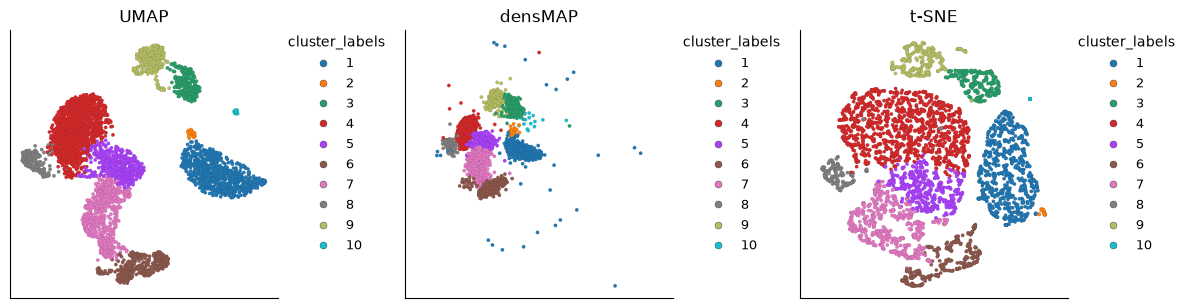

In [12]:
# Create one plotting axis for each comparison panel.
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
# Pair each saved layout with its display title.
layout_comparisons = (("UMAP", umap), ("densMAP", densmap), ("t-SNE", tsne))
# Draw each comparison on its own labeled axis.
for axis, (title, layout) in zip(axes, layout_comparisons, strict=True):
    # Compare UMAP, densMAP, and t-SNE with the same cluster colors.
    ds.plots.embedding(
        layout=layout,
        color_by=cluster_refs[15],
        target=axis,
        show_titles=False,
        show=False,
    )
    # Label the panel with the quantity being compared.
    axis.set_title(title)
# Adjust spacing so panel labels remain readable.
figure.tight_layout()
# Display the completed figure.
figure